# Dimensionaalsuse vähendamine

Põhineb kursuse põhiõpiku (S. Raschka, Python Machine Learning) [peatükil 5.](https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch05/ch05.ipynb)


Vt ka [scikit-learn Decompositions dokumentatsiooni](https://scikit-learn.org/stable/modules/decomposition.html#decompositions).

## Sisukord

* [Ülesanne 6.1](#6_1)
* [Peakomponentide analüüs](#PCA_det)
* [Ülesanne 6.2](#6_2)


Dimensionaalsuse vähendamine/leidmine (*feature extraction*) tähendab uute kunstlike atribuutide defineerimist olemasolevate atribuutide kombinatsioonina. Eesmärgiks on atribuutide arvu vähendamine asendades iga tugevas positiivses/negatiivses korrelatsioonis olevate atribuutide grupi ühe uue atribuudiga.

In [108]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

w_data = load_wine()
print(w_data.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

Esmalt vaatame peakomponente kliendi vaates, märkmiku teises pooles ([Peakomponentide analüüs](#PCA_det)) vaatame nende teooriat ja leidmise meetodeid.

PCA (*Principal Component Analysis*, peakomponentanalüüs)  leiab  uued atribuudid (dimensioonid) ehk komponendid olemasoleva $d$ atribuuti (dimensioonide) lineaarse kombinatsioonina.  $j$-ndale peakomponendile vastab kaaluvektor $\textbf{w}^{(j)} = (w_1, \ldots, w_d)^{(j)}$. 

Rea $i$ peakomponendi $j$ väärtuseks on kaaluvektori $\textbf{w}^{(j)}$  skalaarkorrutis reavektoriga $\textbf{x}^{(i)}$:
$$t_{ij} = \textbf{x}^{(i)} \cdot \textbf{w}^{(j)} = 
x_1^{(i)} \cdot w_1^{(j)} + \ldots + x_d^{(i)} \cdot w_d^{(j)} $$

Kaal $w_k^{(j)}$ kirjeldab seega atribuudi $k$ olulisust komponendis $j$ ja selle märk vastava atribuudi mõju suunda komponendis. Seega peakomponent on  muutujate $x_1, x_2, ... x_d$ lineaarfunktsioon. Näiteks iiriste andmestiku esimene peakomponent on $0.5 sepal length - 0.3 sepal width + 0.6 petal length + 0.6 petal width$.

Esitades algse andmestiku $n \times d$ maatriksina $X$ ja peakomponentide kaaluvektorid $d \times k$ maatriksina $W$ leiame nende maatrikskorrutisena uue teisendatud $n \times k$ maatriksi  $T$, kus $n$ on ridade arv ja $k$ on peakomponentide arv:

$$T=XW$$

Kuna peakomponendid seletavad andmete variatsiooni, siis on tüüpjuhul, kui soovime atribuutide võrdset kaalu ja n korda suurema standardhälbega atribuut ei ole n korda olulisem, vaja andmete standardiseerimist.

In [137]:
# Standardiseerimine on üldjuhul PCA jaoks vajalik
X = StandardScaler().fit_transform(w_data.data) # proovi ilma, väga erinev
# X = w_data.data
pca = PCA(n_components=5)
# pca.fit(w_data.data)
pca.fit(X)

print("Peakomponentide maatriks")
print("(k, d):", pca.components_.shape)
print("W:\n", pca.components_.round(1))


Peakomponentide maatriks
(k, d): (5, 13)
W:
 [[ 0.1 -0.2 -0.  -0.2  0.1  0.4  0.4 -0.3  0.3 -0.1  0.3  0.4  0.3]
 [-0.5 -0.2 -0.3  0.  -0.3 -0.1  0.  -0.  -0.  -0.5  0.3  0.2 -0.4]
 [-0.2  0.1  0.6  0.6  0.1  0.1  0.2  0.2  0.1 -0.1  0.1  0.2 -0.1]
 [-0.   0.5 -0.2  0.1 -0.4  0.2  0.2 -0.2  0.4  0.1 -0.4  0.2 -0.2]
 [-0.3  0.  -0.1  0.1  0.7 -0.1 -0.1 -0.5  0.1 -0.1 -0.2 -0.1 -0.2]]


In [138]:
comp_frame = pd.DataFrame(pca.components_, columns=w_data.feature_names)
comp_frame.T

,0,1,2,3,4
alcohol,0.144329,-0.483652,-0.207383,-0.017856,-0.265664
malic_acid,-0.245188,-0.224931,0.089013,0.536890,0.035214
ash,-0.002051,-0.316069,0.626224,-0.214176,-0.143025
alcalinity_of_ash,-0.239320,0.010591,0.612080,0.060859,0.066103
magnesium,0.141992,-0.299634,0.130757,-0.351797,0.727049
total_phenols,0.394661,-0.065040,0.146179,0.198068,-0.149318
flavanoids,0.422934,0.003360,0.150682,0.152295,-0.109026
nonflavanoid_phenols,-0.298533,-0.028779,0.170368,-0.203301,-0.500703
proanthocyanins,0.313429,-0.039302,0.149454,0.399057,0.136860
color_intensity,-0.088617,-0.529996,-0.137306,0.065926,-0.076437


Peakomponendid on järjestatud seletatud variatsiooni alusel. Seega me teame, millised peakomponendid me peame esmajärjekorras kasutusele võtma, aga kas me soovime rohkem variatsiooni seletada suurema arvu peakomponentidega või vähem variatsiooni seletada väiksema arvu peakomponentidega on valiku koht.

In [139]:
print("Peakomponentide seletatud variatsioon")
print(pca.explained_variance_.round(3)) 
print(pca.explained_variance_ratio_.round(3), sum(pca.explained_variance_ratio_))  

Peakomponentide seletatud variatsioon
[4.732 2.511 1.454 0.924 0.858]
[0.362 0.192 0.111 0.071 0.066] 0.8016229275554787


In [134]:
# Saab ka nii n% variatsiooni jagu komponente küsida,
# reaalarvuline argument on soovitud seletatud variatsiooni suhtarv
pca2 = PCA(n_components=0.9)
pca2.fit(X)
print("90% variatsioonist seletab", pca2.components_.shape[0], "komponenti")

90% variatsioonist seletab 8 komponenti


In [135]:
pca2.components_

array([[ 0.1443294 , -0.24518758, -0.00205106, -0.23932041,  0.14199204,
         0.39466085,  0.4229343 , -0.2985331 ,  0.31342949, -0.0886167 ,
         0.29671456,  0.37616741,  0.28675223],
       [-0.48365155, -0.22493093, -0.31606881,  0.0105905 , -0.299634  ,
        -0.06503951,  0.00335981, -0.02877949, -0.03930172, -0.52999567,
         0.27923515,  0.16449619, -0.36490283],
       [-0.20738262,  0.08901289,  0.6262239 ,  0.61208035,  0.13075693,
         0.14617896,  0.1506819 ,  0.17036816,  0.14945431, -0.13730621,
         0.08522192,  0.16600459, -0.12674592],
       [-0.0178563 ,  0.53689028, -0.21417556,  0.06085941, -0.35179658,
         0.19806835,  0.15229479, -0.20330102,  0.39905653,  0.06592568,
        -0.42777141,  0.18412074, -0.23207086],
       [-0.26566365,  0.03521363, -0.14302547,  0.06610294,  0.72704851,
        -0.14931841, -0.10902584, -0.50070298,  0.13685982, -0.07643678,
        -0.17361452, -0.10116099, -0.1578688 ],
       [-0.21353865, -0.536813

In [114]:
X_t = pca.transform(X)
print("(n, k):", X_t.shape)
print("(X_t (valemis T):\n", X_t.round(2))

(n, k): (178, 5)
(X_t (valemis T):
 [[ 3.32 -1.44 -0.17 -0.22  0.69]
 [ 2.21  0.33 -2.03 -0.29 -0.26]
 [ 2.52 -1.03  0.98  0.72 -0.25]
 [ 3.76 -2.76 -0.18  0.57 -0.31]
 [ 1.01 -0.87  2.03 -0.41  0.3 ]
 [ 3.05 -2.12 -0.63 -0.52 -0.63]
 [ 2.45 -1.17 -0.98 -0.07 -1.03]
 [ 2.06 -1.61  0.15 -1.19  0.08]
 [ 2.51 -0.92 -1.77  0.06 -0.89]
 [ 2.75 -0.79 -0.98  0.35 -0.47]
 [ 3.48 -1.3  -0.42  0.03 -0.34]
 [ 1.75 -0.61 -1.19 -0.89 -0.74]
 [ 2.11 -0.68 -0.87 -0.36 -1.21]
 [ 3.46 -1.13 -1.2   0.16 -2.02]
 [ 4.31 -2.1  -1.26  0.31 -1.03]
 [ 2.31 -1.66  0.22 -1.44 -0.47]
 [ 2.17 -2.33  0.83 -0.91 -0.  ]
 [ 1.9  -1.63  0.79 -1.08 -0.44]
 [ 3.54 -2.52 -0.49 -0.91 -1.15]
 [ 2.08 -1.06 -0.16  0.48  0.88]
 [ 3.12 -0.79 -0.36 -0.03  0.97]
 [ 1.09 -0.24  0.94  1.03  0.32]
 [ 2.54  0.09 -0.31 -0.05 -0.43]
 [ 1.64  0.52  0.14 -0.41 -0.38]
 [ 1.76  0.32  0.89 -0.12 -0.56]
 [ 0.99 -0.94  3.82 -1.32  0.16]
 [ 1.78 -0.69 -0.09 -0.23 -1.14]
 [ 1.24  0.09 -1.39 -0.5  -0.38]
 [ 2.19 -0.69  1.39 -0.78 -0.81]
 [ 2.26

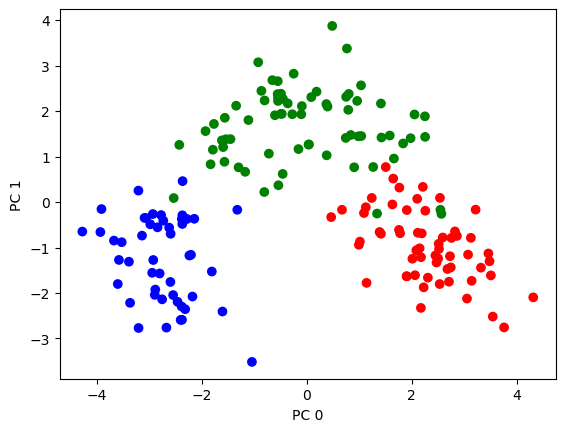

In [115]:
# Kuva objektid kahte oluliseimat komponenti pidi

import matplotlib.pyplot as plt
%matplotlib inline

colormap = {0: "red", 1: "green", 2: "blue"}

plt.scatter(X_t[:, 0], X_t[:, 1], c=[colormap[y] for y in w_data.target])
#plt.scatter(X[:, 5], X[:, 6], c=[colormap[y] for y in w_data.target]) # esimesed 2 attr
plt.xlabel('PC 0')
plt.ylabel('PC 1')
plt.show()

In [116]:
# import seaborn as sns
# X_df = pd.DataFrame(X, columns=w_data.feature_names)
# grid = sns.pairplot(X_df)

<a id='6_1'></a>
## Ülesanne 6.1

Koostada standardiseeritud loomaaia andmestikule (fail `standardiseeritud_zoo.csv` Moodlest)  peakomponentanalüüs:
* Tõsta andmestikust välja (DataFrame `pop()` meetodi abil) veerg `type` ja omistada see mingile muutujale hilisemaks graafiku joonistamiseks.
* Leida sklearn [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)  klassi abil mitut komponenti on vaja, et seletada vähemalt 80% andmestiku varieeruvusest (PCA atribuut `explained_variance_ratio_`)
* Leida need komponendid ja kuvada atribuutide kaalud komponentides
* Transformeerida andmestik nõnda, et atribuutideks on komponendid, mis seletavad vähemalt 80% andmestiku varieeruvusest
* Joonistada graafik (`plt.scatter()`), kus on kujutatud loomad kahe suurima omaväärtusega (seletatud variatsiooniga) peakomponenti pidi ja värviga nende tüübid (0-7).
* Anda kahele suurima kaaluga peakomponendile sisuline interpretatsioon, vaadeldes suure absoluutväärtusega kaale komponentides (stiilis 'komponent 0 näitab veeloomaks olemist'). Millised loomad omavad vastava peakomponendi kõrget või madalat väärtust (`zoo_df[X_t[:, 0] > 0].index` vms)? Millised tüübid eristuvad graafikul selgelt? Panna vastused kirja Markdown lahtrisse. 

In [117]:
import pandas as pd
standariseeritud_zoo_df = pd.read_csv(r"C:\Users\Maive\Desktop\6.semester\Andmekaeve\standardiseeritud_zoo.csv")

veerg_type = standariseeritud_zoo_df.pop('type') # Eemalda DataFramest veerg type ja omista see veerg muutujale
standariseeritud_zoo_df

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,aardvark,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,-1.698416,-0.384353,1.138180
1,antelope,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,-1.115547,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180
2,bass,-0.861034,-0.496904,0.843721,-0.826640,-0.558291,1.343710,0.896421,0.809776,0.46569,-1.951800,-0.293294,2.222876,-1.404435,0.588784,-0.384353,-0.878595
3,bear,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,-1.698416,-0.384353,1.138180
4,boar,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,-1.115547,0.809776,0.46569,0.512348,-0.293294,-0.449868,-0.415948,0.588784,-0.384353,1.138180
97,wasp,1.161395,-0.496904,0.843721,-0.826640,1.791182,-0.744208,-1.115547,-1.234909,-2.14735,0.512348,3.409545,-0.449868,1.561027,-1.698416,-0.384353,-0.878595
98,wolf,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180
99,worm,-0.861034,-0.496904,0.843721,-0.826640,-0.558291,-0.744208,-1.115547,-1.234909,-2.14735,0.512348,-0.293294,-0.449868,-1.404435,-1.698416,-0.384353,-0.878595


In [118]:
# Leia mitu komponenti on vaja, et seletada vähemalt 80% andmestiku varieeruvusest
pca = PCA(n_components=0.8)
pca.fit(standariseeritud_zoo_df.iloc[:,1:].values) #Ei arvesta esimest veergu, sest selles on loomade nimed
print("80% variatsioonist seletab", pca.components_.shape[0], "komponenti")


80% variatsioonist seletab 6 komponenti


In [119]:
# Leida need komponendid ja kuvada atribuutide kaalud komponentides
atribuutide_kaalud_komponentides = pd.DataFrame(pca.components_.T, index=standariseeritud_zoo_df.columns[1:]) 
# Annab atribuutide kaalud kuues komponendis, mida suurem on atribuudi kaal komponendis, seda olulisem see selles komponendis on, märk näitab suunda
atribuutide_kaalud_komponentides 

,0,1,2,3,4,5
hair,-0.407817,-0.113788,0.100052,0.055304,0.009810,-0.061612
feathers,0.201568,-0.192502,-0.483015,-0.178094,0.036435,0.196253
eggs,0.431587,-0.005131,-0.041780,0.014262,-0.091265,0.053563
milk,-0.444796,0.001635,0.012673,-0.030478,-0.056348,-0.016135
airborne,0.195420,-0.311645,-0.278304,0.041590,0.074018,-0.099996
aquatic,0.204870,0.373556,0.063088,-0.069441,-0.060612,0.192144
predator,0.029016,0.252801,0.117730,-0.578215,0.226857,0.345999
toothed,-0.322981,0.320715,0.023563,0.165525,0.094193,-0.199457
backbone,-0.205444,0.204606,-0.476420,-0.016102,0.132586,-0.014695
breathes,-0.210415,-0.366020,-0.189711,-0.166973,0.113468,-0.099012


In [121]:
# Transformeerida andmestik nii, et atribuutideks on komponendid, mis seletavad vähemalt 80% andmestiku varieeruvusest
transformeeritud_zoo_df = standariseeritud_zoo_df.iloc[:,1:] @ atribuutide_kaalud_komponentides
transformeeritud_zoo_df = transformeeritud_zoo_df.set_index(standariseeritud_zoo_df['animal_name'])
print(transformeeritud_zoo_df.shape)
transformeeritud_zoo_df

(101, 6)


,0,1,2,3,4,5
animal_name,,,,,,
aardvark,-2.535256,-0.260278,1.241842,-1.065734,-0.296433,0.261767
antelope,-2.877354,-0.401547,-0.100018,-0.014988,-0.308969,-0.627116
bass,1.761003,3.705592,-0.180105,0.578327,-0.327066,-0.379035
bear,-2.535256,-0.260278,1.241842,-1.065734,-0.296433,0.261767
boar,-2.818975,0.107081,0.136852,-1.178338,0.147460,0.069023
...,...,...,...,...,...,...
wallaby,-2.764120,-0.065219,-0.409317,0.151818,-0.235706,-0.786741
wasp,1.667523,-3.219581,2.723445,0.743239,2.290063,-0.896837
wolf,-2.818975,0.107081,0.136852,-1.178338,0.147460,0.069023


Loomade klassid (types 1-7)
1 -- (41) aardvark, antelope, bear, boar, buffalo, calf, cavy, cheetah, deer, dolphin, elephant, fruitbat, giraffe, girl, goat, gorilla, hamster, hare, leopard, lion, lynx, mink, mole, mongoose, opossum, oryx, platypus, polecat, pony, porpoise, puma, pussycat, raccoon, reindeer, seal, sealion, squirrel, vampire, vole, wallaby,wolf
2 -- (20) chicken, crow, dove, duck, flamingo, gull, hawk, kiwi, lark, ostrich, parakeet, penguin, pheasant, rhea, skimmer, skua, sparrow, swan, vulture, wren
3 -- (5)  pitviper, seasnake, slowworm, tortoise, tuatara 
4 -- (13) bass, carp, catfish, chub, dogfish, haddock, herring, pike, piranha, seahorse, sole, stingray, tuna
5 -- (4)  frog, frog, newt, toad 
6 -- (8)  flea, gnat, honeybee, housefly, ladybird, moth, termite, wasp
7 -- (10) clam, crab, crayfish, lobster, octopus, scorpion, seawasp, slug, starfish, worm

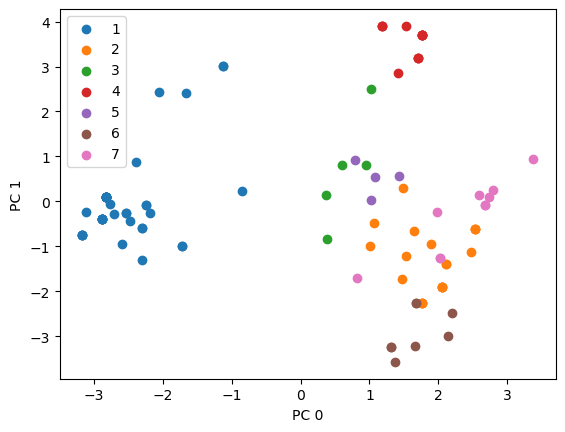

In [123]:
# Joonistada graafik (`plt.scatter()`), kus on kujutatud loomad kahe suurima omaväärtusega (seletatud variatsiooniga) peakomponenti pidi ja värviga nende tüübid (0-7).
for t in np.unique(veerg_type):
    plt.scatter(transformeeritud_zoo_df.iloc[(veerg_type == t).values, 0], transformeeritud_zoo_df.iloc[(veerg_type == t).values, 1], label=t)

plt.xlabel('PC 0')
plt.ylabel('PC 1')
plt.legend()
plt.show()

# Graafikul eristub väga selgelt 1. tüüp, 4. tüüp ning üsna hästi ka 6. tüüp. 2.,  3., 5. ja 7. tüüpil on graafikul ühisosa.

In [125]:
# 0. komponent

# Leian, mis loomadel on 0. komponendis madalad ja mis loomadel kõrged väärtused 
standariseeritud_zoo_df.loc[(transformeeritud_zoo_df.iloc[:, 0] < -2.5).values, 'animal_name'] # Need loomad, kellel esimese komponendi väärtus on miinus kahest väiksem (omavad madalat väärtust)
# imetajad omavad madalat väärtust
standariseeritud_zoo_df.loc[(transformeeritud_zoo_df.iloc[:, 0] > 2.5).values, 'animal_name'] # Loomad, kes omavad komponendi kõrget väärtust
# Kõrget komponendi väärtust omavad nt krabi, vähk, meritäht

# Leian kui suure kaaluga on atribuudid 0. komponendis
atribuutide_kaalud_komponentides.iloc[:, [0]].sort_values(by=[0], ascending=False) 
# Suure positiivse kaalgu on atribuudid: muneb, veeloom, suled
# Suure negatiivse kaaluga on imetamine, karvad, hammastega

,0
eggs,0.431587
aquatic,0.204870
feathers,0.201568
airborne,0.195420
venomous,0.095618
fins,0.081755
predator,0.029016
domestic,-0.096818
legs,-0.114553
tail,-0.124046


In [126]:
# 1. komponent

# Leian, mis loomadel on 1. komponendis madalad ja mis loomadel kõrged väärtused 
standariseeritud_zoo_df.loc[(transformeeritud_zoo_df.iloc[:, 1] < -2).values, 'animal_name'] # Need loomad, kes omavad komponendi madalat väärtust
# Linnud ja putukad omavad madalat väärtust
standariseeritud_zoo_df.loc[(transformeeritud_zoo_df.iloc[:, 1] > 3).values, 'animal_name'] # Loomad, kes omavad komponendi kõrget väärtust
# Kõrget komponendi väärtust omavad kalad, delfiin

# Leian kui suure kaaluga on atribuudid 1. komponendis
atribuutide_kaalud_komponentides.iloc[:, [1]].sort_values(by=[1], ascending=False) 
# Suure positiivse kaalgu on atribuudid: uimed (fins), veeloom, hammastega, kiskja
# Suure negatiivse kaaluga on hingab, jalad, lendab (airborne)

,1
fins,0.454631
aquatic,0.373556
toothed,0.320715
predator,0.252801
backbone,0.204606
tail,0.160615
catsize,0.092983
venomous,0.002572
milk,0.001635
eggs,-0.005131


* Peakomponent 0 näitab imetajaks mitte olemist.
* Peakomponent 1 näitab uimedega liikumist, madala väärtusega on loomad, kes lendavad ning vahepeale jäävad roomajad-kõndijad

<a id='PCA_det'></a>
## Peakomponentide analüüs

Peakomponendid on atribuutide kovariatsioonimaatriksi omavektorid. Vastavad atribuutide kovariatsioonimaatriksi omaväärtused määravad nende peakomponentide olulisuse ehk seletatud variatsiooni.  Järgnevalt vaatleme nende leidmist lähemalt.

Sammud:

* Standardiseeri $d$-dimensionaalne (atribuudiga) andmestik $X$
* Konstrueeri $d \times d$ atribuutide kovariatsioonimaatriks $\Sigma$
* Leia $\Sigma$ omavektorid ja omaväärtused
* Vali $k$ suurimale omaväärtusele vastavat omavektorit ja konstrueeri nendest projektisoonimaatriks $W$
* Teisenda $X$ kasutades projektsioonimaatriksit $W$

Kovariatsioon $\sigma_{jk}$ atribuutide $j, k$ vahel, summeerides üle $i = 1...n$ rea ($\mu$ on keskväärtus):
    
$$ \sigma_{jk} = \frac{1}{n} \sum_{i=1}^n (x_j^{(i)} - \mu_j)(x_k^{(i)} - \mu_k)$$

*(Korrelatsioon on kovariatsioon jagatud mõlema atribuudi standardhälvetega. Standardiseeritud andmete korral, kus standardhälve on 1, langevad kovariatsioon ja korrelatsioon kokku.)*

Tulemuseks on kovariatsioonimaatriks $\Sigma$ (*Sigma*):
    $$ \Sigma = \begin{bmatrix}
    \sigma_{11} & \sigma_{12} &  \dots  & \sigma_{1d} \\
    \sigma_{21} & \sigma_{22} &  \dots  & \sigma_{2d} \\
    \vdots & \vdots &  \ddots & \vdots \\
    \sigma_{d1} & \sigma_{d2}  & \dots  & \sigma_{dd}
\end{bmatrix} $$

Korrelatsiooni- või kovariatsioonimaatriks on ka üldiselt kasulik vahend uurimuslikuks andmete eelanalüüsiks.

In [127]:
# Loo kovariatsioonimaatriks

kov = np.cov(X.T)
print(kov.shape)
display(pd.DataFrame(kov, columns=w_data.feature_names, index=w_data.feature_names))



(13, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.005650,0.094930,0.212740,-0.311988,0.272328,0.290734,0.238153,-0.156810,0.137470,0.549451,-0.072153,0.072752,0.647357
malic_acid,0.094930,1.005650,0.164972,0.290130,-0.054883,-0.337061,-0.413329,0.294632,-0.221993,0.250392,-0.564467,-0.370794,-0.193095
ash,0.212740,0.164972,1.005650,0.445872,0.288206,0.129708,0.115727,0.187283,0.009706,0.260350,-0.075089,0.003933,0.224890
alcalinity_of_ash,-0.311988,0.290130,0.445872,1.005650,-0.083804,-0.322928,-0.353355,0.363966,-0.198442,0.018838,-0.275503,-0.278332,-0.443086
magnesium,0.272328,-0.054883,0.288206,-0.083804,1.005650,0.215613,0.196890,-0.257742,0.237776,0.201080,0.055711,0.066377,0.395573
total_phenols,0.290734,-0.337061,0.129708,-0.322928,0.215613,1.005650,0.869448,-0.452477,0.615873,-0.055448,0.436132,0.703904,0.500929
flavanoids,0.238153,-0.413329,0.115727,-0.353355,0.196890,0.869448,1.005650,-0.540939,0.656379,-0.173353,0.546549,0.791641,0.496985
nonflavanoid_phenols,-0.156810,0.294632,0.187283,0.363966,-0.257742,-0.452477,-0.540939,1.005650,-0.367912,0.139843,-0.264123,-0.506113,-0.313144
proanthocyanins,0.137470,-0.221993,0.009706,-0.198442,0.237776,0.615873,0.656379,-0.367912,1.005650,-0.025393,0.297214,0.522000,0.332283
color_intensity,0.549451,0.250392,0.260350,0.018838,0.201080,-0.055448,-0.173353,0.139843,-0.025393,1.005650,-0.524761,-0.431238,0.317886


Lineaaralgebrast teame, et omaväärtus $\lambda$ ja omavektor $\mathbf{v}$ on lahendid järgmisele võrrandile:

$$ \Sigma \mathbf{v} = \lambda \mathbf{v} $$

see tähendab pikemalt:


$$\begin{bmatrix}
\sigma_{11} v_1 + \sigma_{12} v_2 +  \dots  + \sigma_{1d} v_d \\
\sigma_{21} v_1 + \sigma_{22} v_2 +  \dots  + \sigma_{2d} v_d \\
\vdots  \\
\sigma_{d1} v_1 + \sigma_{d2} v_2 + \dots  + \sigma_{dd} v_d
\end{bmatrix} = \begin{bmatrix} \lambda v_1 \\ \lambda v_2 \\ \vdots \\ \lambda v_d\end{bmatrix} $$



Omavektorite ja omaväärtuste osas võib lisaks vaadata ka P. Puusempa Lineaaralgebra õpikut või [3Blue1Brown omavektorite YT videot](https://youtu.be/PFDu9oVAE-g).

Nimetame vektori $\mathbf{v}$ ümber vektoriks $\mathbf{w}$, et järgida meie tavalist kaaluvektorite tähistust: 

$$ \Sigma \mathbf{w} = \lambda \mathbf{w} $$.

Iga PCA kaaluvektor $\textbf{w}^{(j)}$ ongi maatriksi $X$ kovariatsioonimaatriksi omavektor, seega vastavalt omavektori definitsioonile peab selle vektori atribuudile $k$ vastav komponent rahuldama võrrandit:

$$ w_k^{(j)} = \frac{1}{\lambda} (\sigma_{k1} w_1^{(j)} + \sigma_{k2} w_2^{(j)} +  \dots + \sigma_{kk} w_k^{(j)} + \dots + \sigma_{kd} w_d^{(j)} ) $$

Atribuudi $k$ kaal $w_k$ on konstandiga $\lambda$ korrigeeritud summa teiste atribuutide kaalude korrutisest atribuudi $k$ ja teise atribuudi kovariatsiooniga. Rekursiivne definitsioon: kaal on defineeritud teiste kaalude summa abil. Selline kaalude süsteem omab palju lahendeid (peakomponente).

Seega mõjutavad atribuudi kaalu $w_k^{(j)}$ eriti need atribuudid $g$, mis on atribuudiga $k$ tugevas positiivses või negatiivses kovariatsioonis $\sigma_{kg}$  ja millele  vastav kaalukomponent $w_g^{(j)}$ on suure absoluutväärtusega. Kui sellised korrutised $\sigma_{kg} w_g^{(j)}$ on kooskõlaliste märkidega, siis  on kaal $w_k^{(j)}$ kõrge. Siit tuleneb interpretatsioon, et kovariatsioonimaatriksi omavektorid ehk peakomponendid vastavad omavahelist tugevat positiivset või negatiivset korrelatsiooni/kovariatsiooni omavatele algsete atribuutide gruppidele. Lisaks näeme, et mida suurem on omaväärtus $\lambda$, seda suurem peab olema sulgudes summa (seletatud variatsioon), mida $\frac{1}{\lambda}$ korrigeerib.

Peakomponendi kaalusid võib interpreteerida kui algse atribuudi olulisust või mõju peakomponendis. Eeldame, et me tahame teada mingi atribuudi kaalu teades ülejäänud atribuutide kaalusid meie peakomponendis ja kovariatsioonimaatriksit. On loomulik, et defineerime otsitava atribuudi kaalu peakomponendis korrutades teiste atribuutide kaalud läbi nende kovariatsiooniga meie atribuudi suhtes, mis annab meile jällegi tuttava PCA lineaarvõrrandi: 
$w_k^{(j)} = \frac{1}{\lambda} (\sigma_{k1} w_1^{(j)} + \sigma_{k2} w_2^{(j)} +  \dots + \sigma_{kk} w_k^{(j)} + \dots + \sigma_{kd} w_d^{(j)})$.

Arvutame kovariatsioonimaatriksile omaväärtused ja omavektorid ja teisendame andmed viie peakomponendiga.

In [128]:
oma_vrt, oma_vkt = np.linalg.eig(kov)
print(oma_vrt)
#NB! omavektorid on veerud!
display(pd.DataFrame(oma_vkt, index=w_data.feature_names))

[4.73243698 2.51108093 1.45424187 0.92416587 0.85804868 0.64528221
 0.55414147 0.10396199 0.35046627 0.16972374 0.29051203 0.22706428
 0.25232001]


,0,1,2,3,4,5,6,7,8,9,10,11,12
alcohol,-0.144329,0.483652,-0.207383,0.017856,-0.265664,0.213539,0.056396,-0.014970,0.396139,-0.266286,-0.508619,-0.225917,0.211605
malic_acid,0.245188,0.224931,0.089013,-0.536890,0.035214,0.536814,-0.420524,-0.025964,0.065827,0.121696,0.075283,0.076486,-0.309080
ash,0.002051,0.316069,0.626224,0.214176,-0.143025,0.154475,0.149171,0.141218,-0.170260,-0.049622,0.307694,-0.498691,-0.027125
alcalinity_of_ash,0.239320,-0.010591,0.612080,-0.060859,0.066103,-0.100825,0.286969,-0.091683,0.427970,-0.055743,-0.200449,0.479314,0.052799
magnesium,-0.141992,0.299634,0.130757,0.351797,0.727049,0.038144,-0.322883,-0.056774,-0.156361,0.062220,-0.271403,0.071289,0.067870
total_phenols,-0.394661,0.065040,0.146179,-0.198068,-0.149318,-0.084122,0.027925,0.463908,-0.405934,-0.303882,-0.286035,0.304341,-0.320131
flavanoids,-0.422934,-0.003360,0.150682,-0.152295,-0.109026,-0.018920,0.060685,-0.832257,-0.187245,-0.042899,-0.049578,-0.025694,-0.163151
nonflavanoid_phenols,0.298533,0.028779,0.170368,0.203301,-0.500703,-0.258594,-0.595447,-0.114040,-0.233285,0.042352,-0.195501,0.116896,0.215535
proanthocyanins,-0.313429,0.039302,0.149454,-0.399057,0.136860,-0.533795,-0.372139,0.116917,0.368227,-0.095553,0.209145,-0.237363,0.134184
color_intensity,0.088617,0.529996,-0.137306,-0.065926,-0.076437,-0.418644,0.227712,0.011993,-0.033797,0.604222,-0.056218,0.031839,-0.290775


Peakomponentide interpreteerimine põhineb algsete atribuutide leidmisel, mis on selles komponendis suure positiivse või negatiivse kaaluga. Näiteks ülaltoodud peakomponendis indeksiga 0 on nendeks -0.42 *flavanoids*, -0.39 *total_phenols*, -0.38 *od280/od315*, - 0.31 *proanthocyanins* ja +0.3 *nonflavanoid_phenols*. Näeme, et kõik peale *nonflavanoid_phenols* on miinusmärgiga ja mõjutavad komponenti samas suunas. Vaadates lisaks kaalukaid atribuute *flavanoids*, *total_phenols* ja  *proanthocyanins* (teatud tüüpi flavonoid, mis annab punase värvi) võime eeldada, et see peakomponent mõõdab flavonidsete fenoolide määra. Valkude puhtust mõõtev *od280/od315* suhe on flavonoidsete fenoolide määraga positiivses korrelatsioonis.

In [129]:
W = oma_vkt[:, :5] # Vali 5 veergu
X_s = X @ W # Teisenda maatriks X (13 atribuuti) viie peakomponendi (uue atribuudi) kujule
print(X_s.shape)
X_s

(178, 5)


array([[-3.31675081e+00,  1.44346263e+00, -1.65739045e-01,
         2.15631188e-01,  6.93042841e-01],
       [-2.20946492e+00, -3.33392887e-01, -2.02645737e+00,
         2.91358318e-01, -2.57654635e-01],
       [-2.51674015e+00,  1.03115130e+00,  9.82818670e-01,
        -7.24902309e-01, -2.51033118e-01],
       [-3.75706561e+00,  2.75637191e+00, -1.76191842e-01,
        -5.67983308e-01, -3.11841591e-01],
       [-1.00890849e+00,  8.69830821e-01,  2.02668822e+00,
         4.09765788e-01,  2.98457503e-01],
       [-3.05025392e+00,  2.12240111e+00, -6.29395827e-01,
         5.15637495e-01, -6.32018734e-01],
       [-2.44908967e+00,  1.17485013e+00, -9.77094891e-01,
         6.58305046e-02, -1.02776191e+00],
       [-2.05943687e+00,  1.60896307e+00,  1.46281883e-01,
         1.19260801e+00,  7.69034938e-02],
       [-2.51087430e+00,  9.18070957e-01, -1.77096903e+00,
        -5.62703612e-02, -8.92256977e-01],
       [-2.75362819e+00,  7.89437674e-01, -9.84247490e-01,
        -3.49381568e-01

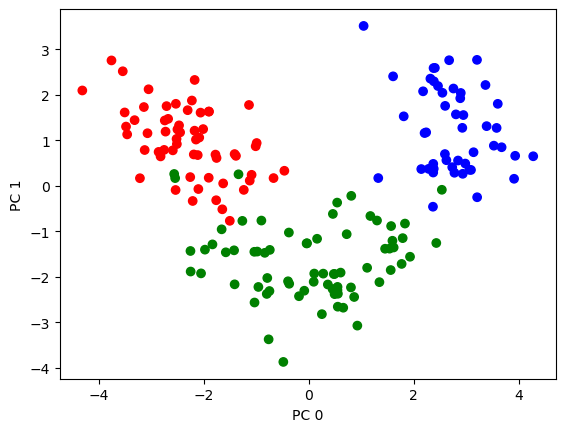

In [130]:
plt.scatter(X_s[:, 0], X_s[:, 1], c=[colormap[y] for y in w_data.target])
plt.xlabel('PC 0')
plt.ylabel('PC 1')
plt.show()

Kontrollime omadust $\Sigma \mathbf{v} = \lambda \mathbf{v}$ jagades vektori $\Sigma \mathbf{v}$ elementhaaval vektoriga $\mathbf{v}$ ja saades tulemusteks $\lambda$-täidetud vektorid.

In [140]:
for i in range(5):
    print("Peakomponent", i)
    print("Meie arvutatud\n", kov @ W[:, i] / W[:, i])
    print("Sklearn\n", kov @ pca.components_[i].T / pca.components_[i].T)


Peakomponent 0
Meie arvutatud
 [4.73243698 4.73243698 4.73243698 4.73243698 4.73243698 4.73243698
 4.73243698 4.73243698 4.73243698 4.73243698 4.73243698 4.73243698
 4.73243698]
Sklearn
 [4.73243698 4.73243698 4.73243698 4.73243698 4.73243698 4.73243698
 4.73243698 4.73243698 4.73243698 4.73243698 4.73243698 4.73243698
 4.73243698]
Peakomponent 1
Meie arvutatud
 [2.51108093 2.51108093 2.51108093 2.51108093 2.51108093 2.51108093
 2.51108093 2.51108093 2.51108093 2.51108093 2.51108093 2.51108093
 2.51108093]
Sklearn
 [2.51108093 2.51108093 2.51108093 2.51108093 2.51108093 2.51108093
 2.51108093 2.51108093 2.51108093 2.51108093 2.51108093 2.51108093
 2.51108093]
Peakomponent 2
Meie arvutatud
 [1.45424187 1.45424187 1.45424187 1.45424187 1.45424187 1.45424187
 1.45424187 1.45424187 1.45424187 1.45424187 1.45424187 1.45424187
 1.45424187]
Sklearn
 [1.45424187 1.45424187 1.45424187 1.45424187 1.45424187 1.45424187
 1.45424187 1.45424187 1.45424187 1.45424187 1.45424187 1.45424187
 1.45424187

Peakomponendid on ortogonaalsed vektorid, st nende omavaheline vektorkorrutis peab olema null, mida me järgnevalt kontrollime.

In [ ]:
# Lisa komponentide maatriksile dimensioonid, 
# tekitades "lamava" ja "püstise" versiooni, 
# millevaheline .dot() operatsioon korrutab 
# kõik reavektorite kombinatsioonid  
row_dot = np.dot(pca.components_[None, :, :], pca.components_[:, :, None])
# eemalda tulemusest "tühjad" dimensioonid
row_dot = row_dot.squeeze()
# Näita ümardatud väljundit
row_dot.round(4)

array([[ 1., -0.,  0.,  0.,  0.],
       [-0.,  1., -0.,  0.,  0.],
       [ 0., -0.,  1.,  0., -0.],
       [ 0.,  0.,  0.,  1., -0.],
       [ 0.,  0., -0., -0.,  1.]])

Vaadates peakomponentide kujule teisendatud andmemaatriksi peakomponentide kovariatsioone näeme, et peakomponentide vaheline kovariatsioon on alati null (ortogonaalsus) ja peakomponendi kovariatsioon iseendaga on selle peakomponendi omaväärtus.

In [ ]:
np.cov(X_s.T).round(4)

array([[ 9.92017895e+04, -0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-0.00000000e+00,  1.72535300e+02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  9.43810000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         4.99120000e+00, -0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -0.00000000e+00,  1.22880000e+00]])

<a id='6_2'></a>
## Ülesanne 6.2

Jätkata tööd ülesande 6.1 andmestikuga:

* Leida andmestiku pealt atribuutide kovariatsioonimaatriks ([numpy.cov(X.T)](https://docs.scipy.org/doc/numpy/reference/generated/numpy.cov.html)) (võib olla vaja andmeid transponeerida, muidu leiab ridade kovariatsioonid). Kas atribuutidevahelised kovariatsioonid on valdavalt positiivsed või negatiivsed? Mis on atribuutide indeksitega 0 ja 1 kovariatsioon?
* Leida selle kovariatsioonimaatriksi omaväärtused ja omavektorid (omavrt, omavektorid = [numpy.linalg.eig()](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eig.html)). NB! omavektorid on väljastatud omavektorite maatriksi **veerud**. Kas need vastavad sklearn.PCA klassi leitud peakomponentidele? Kaaluvektorid võivad olla korrutatud -1-ga, positiivse ja negatiivse ümberpööramine dimensiooni sisu ei muuda.
* Kontrolliks korrutada algne andmemaatriks $X$ leitud omavektorite maatriksiga $W$ läbi ja kuvada tulemuse $XW$ kahe esimese peakomponendi väärtused hajuvusgraafikul (*scatterplot*). Kas see sarnaneb ülesande 6.1 hajuvusgraafikuga?

In [165]:
# Loo kovariatsioonimaatriks
atribuutide_kov_maatriks = np.cov(standariseeritud_zoo_df.T)

display(pd.DataFrame(atribuutide_kov_maatriks, columns=standariseeritud_zoo_df.columns, index=standariseeritud_zoo_df.columns))

# Atribuutide vahelised kovariatsioonid on umbes poolenisti positiivsed ja poolenist negatiivsed

# Suled ja karvad kovariatsioon on -0.4321296771768597
atribuutide_kov_maatriks[0, 1]

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
hair,1.010000,-0.432130,-0.825555,0.887288,-0.200416,-0.478290,-0.156316,0.497456,0.193597,0.445560,-0.105287,-0.283116,0.397949,0.049463,0.209280,0.459570
feathers,-0.432130,1.010000,0.423441,-0.414868,0.663119,-0.059137,-0.105474,-0.619767,0.233717,0.257133,-0.147196,-0.225776,-0.208753,0.295495,0.031902,-0.137294
eggs,-0.825555,0.423441,1.010000,-0.948236,0.380413,0.380006,0.011721,-0.648572,-0.343824,-0.386605,0.099676,0.166444,-0.227168,-0.223300,-0.157166,-0.519797
milk,0.887288,-0.414868,-0.948236,1.010000,-0.370433,-0.366239,-0.030018,0.634450,0.388808,0.427762,-0.244873,-0.157891,0.216338,0.212126,0.165567,0.580655
airborne,-0.200416,0.663119,0.380413,-0.370433,1.010000,-0.174364,-0.298133,-0.600254,-0.105766,0.288899,0.008614,-0.253668,0.044149,0.009577,0.063907,-0.353266
aquatic,-0.478290,-0.059137,0.380006,-0.366239,-0.174364,1.010000,0.379738,0.053681,0.022688,-0.643881,0.088794,0.610536,-0.364244,-0.034989,-0.226551,-0.112985
predator,-0.156316,-0.105474,0.011721,-0.030018,-0.298133,0.379738,1.010000,0.130747,0.051532,-0.265561,0.116544,0.192205,-0.100720,0.019136,-0.312892,0.146237
toothed,0.497456,-0.619767,-0.648572,0.634450,-0.600254,0.053681,0.130747,1.010000,0.580836,-0.066347,-0.062968,0.367935,-0.195411,0.313471,0.070125,0.347450
backbone,0.193597,0.233717,-0.343824,0.388808,-0.105766,0.022688,0.051532,0.580836,1.010000,0.209743,-0.249077,0.211594,-0.437185,0.739080,0.102751,0.360546
breathes,0.445560,0.257133,-0.386605,0.427762,0.288899,-0.643881,-0.265561,-0.066347,0.209743,1.010000,-0.121959,-0.623391,0.373566,0.089841,0.125309,0.206166


-0.4321296771768597

In [189]:
# Leia kovariatsioonimaatriksi omav''rtused ja omavektorid
omavrt, omavektorid = np.linalg.eig(atribuutide_kov_maatriks)
print(omavrt) # omaväärtused määravad peakomponentide olulisuse ehk seletatud variatsiooni.

omavektorid_df = pd.DataFrame(omavektorid, index=standariseeritud_zoo_df.columns) # omavektorid ehk peakomponendid (NB! veerud)
display(omavektorid_df)

# Kas leitud omavektorid vastavad enne leitud peakomponentidele? - Jah
abs(round(omavektorid_df[[0, 1, 2, 3, 4, 5]], 6)) == abs(round(atribuutide_kaalud_komponentides, 6))

[4.71728026 3.37467724 2.38816089 1.24324681 0.96347757 0.75349382
 0.01796122 0.03663427 0.11912161 0.13083722 0.21283481 0.28035829
 0.56844114 0.5175513  0.38365316 0.4522704 ]


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
hair,-0.407817,0.113788,0.100052,0.055304,-0.009810,-0.061612,0.134120,0.317488,0.372411,-0.574972,-0.240441,0.126364,-0.075160,0.334982,-0.155125,0.001301
feathers,0.201568,0.192502,-0.483015,-0.178094,-0.036435,0.196253,-0.380512,0.305939,0.493570,0.230970,0.010596,0.271401,-0.025643,0.022995,0.053902,0.065118
eggs,0.431587,0.005131,-0.041780,0.014262,0.091265,0.053563,-0.415846,-0.238605,0.053418,-0.567182,-0.309095,-0.339431,-0.028902,-0.138576,0.119943,-0.031190
milk,-0.444796,-0.001635,0.012673,-0.030478,0.056348,-0.016135,-0.521173,-0.604890,0.013459,-0.024282,0.192532,0.264907,0.010460,0.199352,-0.054392,0.096391
airborne,0.195420,0.311645,-0.278304,0.041590,-0.074018,-0.099996,0.009858,-0.078151,-0.363451,0.154463,-0.242073,-0.154557,-0.109598,0.669797,-0.252886,0.028090
aquatic,0.204870,-0.373556,0.063088,-0.069441,0.060612,0.192144,0.011355,0.112444,-0.179694,-0.165416,0.184670,0.296649,-0.025432,0.480034,0.547432,-0.209284
predator,0.029016,-0.252801,0.117730,-0.578215,-0.226857,0.345999,0.020304,0.008438,-0.007699,-0.061721,-0.006724,-0.163252,0.467649,0.138975,-0.317124,0.215061
toothed,-0.322981,-0.320715,0.023563,0.165525,-0.094193,-0.199457,-0.472996,0.404763,-0.175125,0.231096,-0.324787,-0.258974,0.197235,0.030503,0.178619,0.017127
backbone,-0.205444,-0.204606,-0.476420,-0.016102,-0.132586,-0.014695,0.398109,-0.394496,0.229659,0.070886,-0.373509,-0.085609,0.156455,0.003369,0.357321,0.002809
breathes,-0.210415,0.366020,-0.189711,-0.166973,-0.113468,-0.099012,0.016597,0.128970,-0.100420,-0.201313,0.492219,-0.427508,0.035356,0.028167,0.404508,0.277439


,0,1,2,3,4,5
hair,True,True,True,True,True,True
feathers,True,True,True,True,True,True
eggs,True,True,True,True,True,True
milk,True,True,True,True,True,True
airborne,True,True,True,True,True,True
aquatic,True,True,True,True,True,True
predator,True,True,True,True,True,True
toothed,True,True,True,True,True,True
backbone,True,True,True,True,True,True
breathes,True,True,True,True,True,True


* Kontrolliks korrutada algne andmemaatriks $X$ leitud omavektorite maatriksiga $W$ läbi ja kuvada tulemuse $XW$ kahe esimese peakomponendi väärtused hajuvusgraafikul (*scatterplot*). Kas see sarnaneb ülesande 6.1 hajuvusgraafikuga?



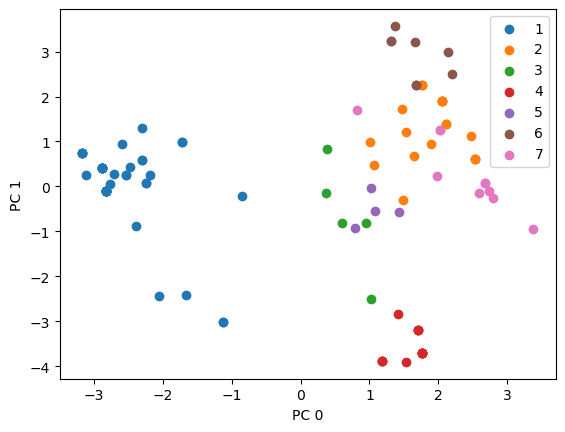

In [196]:
# Korrutada algne andmemaatriks leitud omavektorite maatriksiga, kuvada kahe  esimese peakomponendi v''rtused hajuvusgraafikul
(standariseeritud_zoo_df @ omavektorid)

for t in np.unique(veerg_type):
    plt.scatter((standariseeritud_zoo_df @ omavektorid).iloc[(veerg_type == t).values, 0], (standariseeritud_zoo_df @ omavektorid).iloc[(veerg_type == t).values, 1], label=t)

plt.xlabel('PC 0')
plt.ylabel('PC 1')
plt.legend()
plt.show()

# Jah, antud graafik sarnaneb eelmises ulesande saadud graafikuga (kuid PCA 1 on ümberpööratud)
